# **Лабораторна робота №4**

Виконавець:  <b>Бережна Ольга</b>, група <b>К-27</b>
<br> Викладач: <b>Карнаух Тетяна Олександрівна</b>

<b>Задача 1.</b>
У завданні 2 лабораторної роботи №1 за датами створення файлів для кожного місяця, починаючи з вересня 2024-го року було знайдено таку інформацію: кількість файлів з розширеннями з "білого списку", їх сумарний розмір у байтах, кількість їх рядків (враховувати тільки для файлів категорії C; білі та порожні рядки не рахувати), середній розмір.
Для кожної характеристики по місяцях побудувати: графік, графік з накопиченням, стовпчикову діаграму, стовпчикову діаграму з накопиченням. Графіки розташувати на одному зображенні.

З використанням даних завдання 1 лабораторної роботи №1 побудувати кругову діаграму.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv('lab1_1.csv', sep=';')

In [9]:
df['lines'] = pd.to_numeric(df['lines'], errors='coerce').fillna(0)
df['date'] = df['year'].astype(str) + '-' + df['mon'].astype(str).str.zfill(2)
dates = sorted(df['date'].unique())

In [17]:
def plot_characteristic(dataframe, values_col, title_base):
    pivot_df = dataframe.pivot_table(
        index='date', columns='ext',
        values=values_col, aggfunc='sum', fill_value=0
    )
    x = pivot_df.index
    labels = pivot_df.columns.tolist()
    y_stack = [pivot_df[ext].values for ext in labels]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{title_base} по місяцях', fontsize=18, fontweight='bold')

    for ext in labels:
        axes[0, 0].plot(x, pivot_df[ext], marker='o', label=ext)
    axes[0, 0].set_title('Звичайний графік')
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel(title_base)
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].stackplot(x, y_stack, labels=labels, alpha=0.7)
    axes[0, 1].set_title('Графік з накопиченням')
    axes[0, 1].set_xlabel('Дата')
    axes[0, 1].set_ylabel(title_base)

    x_indexes = np.arange(len(x))
    width = 0.8 / len(labels)
    for i, ext in enumerate(labels):
        axes[1, 0].bar(x_indexes + i * width - 0.4 + width/2,
                       pivot_df[ext], width=width, label=ext)
    axes[1, 0].set_xticks(x_indexes)
    axes[1, 0].set_xticklabels(x)
    axes[1, 0].set_title('Стовпчикова діаграма')
    axes[1, 0].set_xlabel('Дата')
    axes[1, 0].set_ylabel(title_base)

    bottom = np.zeros(len(x))
    for ext in labels:
        axes[1, 1].bar(x, pivot_df[ext], bottom=bottom, label=ext)
        bottom += pivot_df[ext].values
    axes[1, 1].set_title('Стовпчикова діаграма з накопиченням')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].set_ylabel(title_base)

    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    handles, plot_labels = axes[1, 1].get_legend_handles_labels()
    fig.legend(handles, plot_labels, loc='center right', bbox_to_anchor=(1.1, 0.5), title='Розширення')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.savefig(f'plot_{values_col}.png', bbox_inches='tight')
    plt.show()

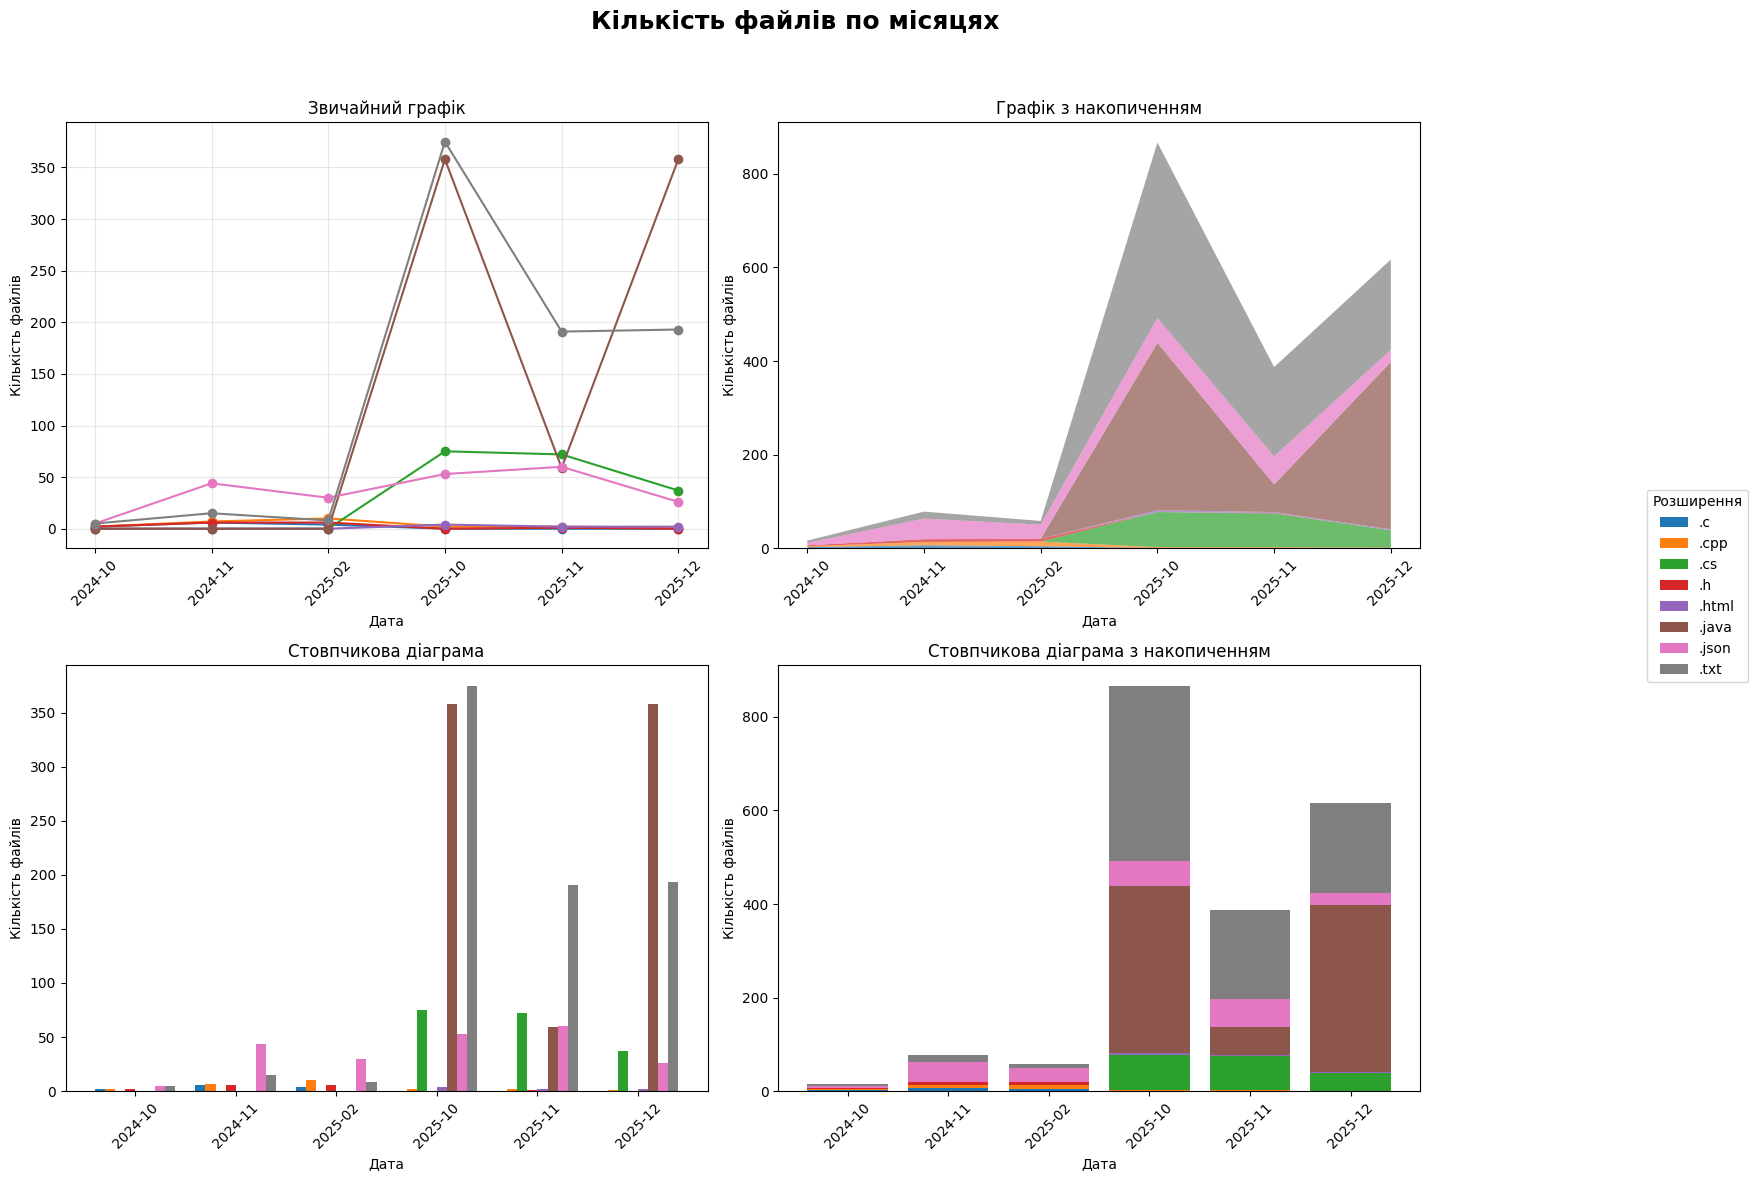

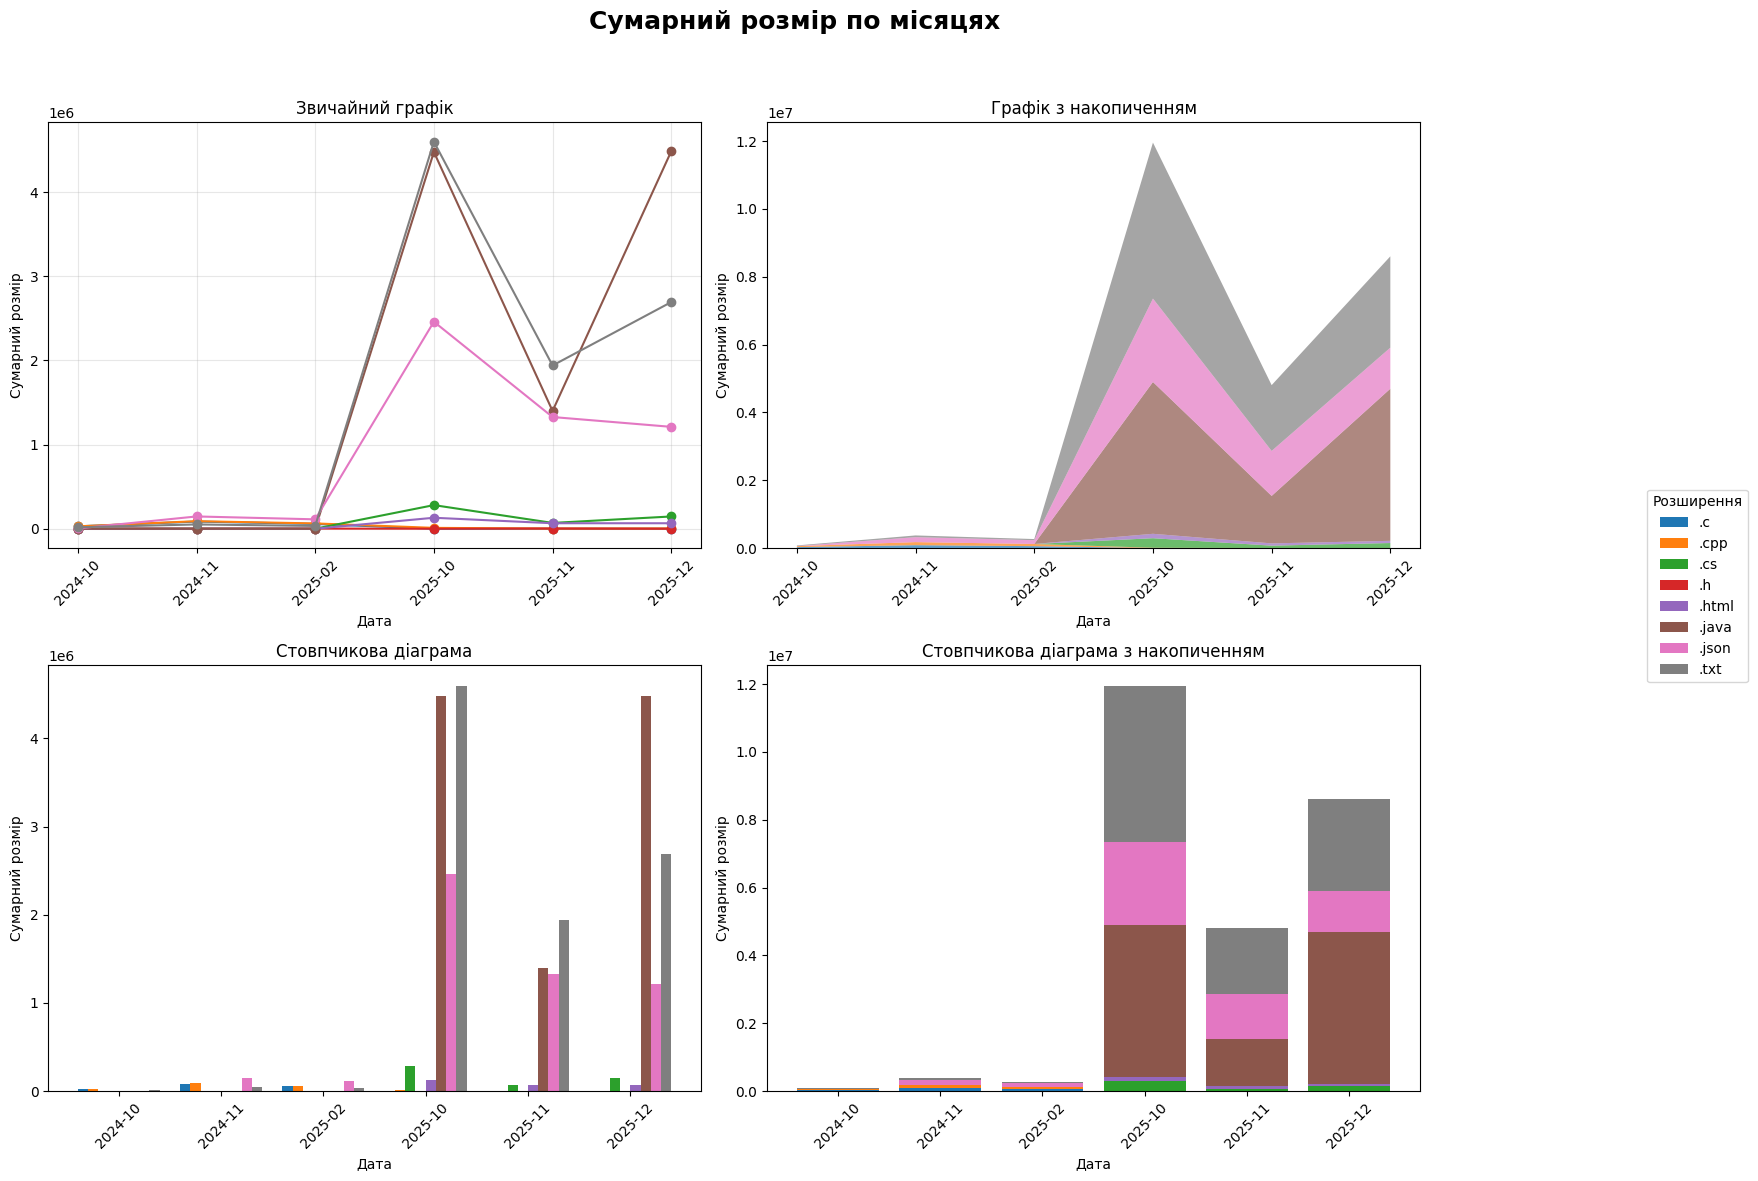

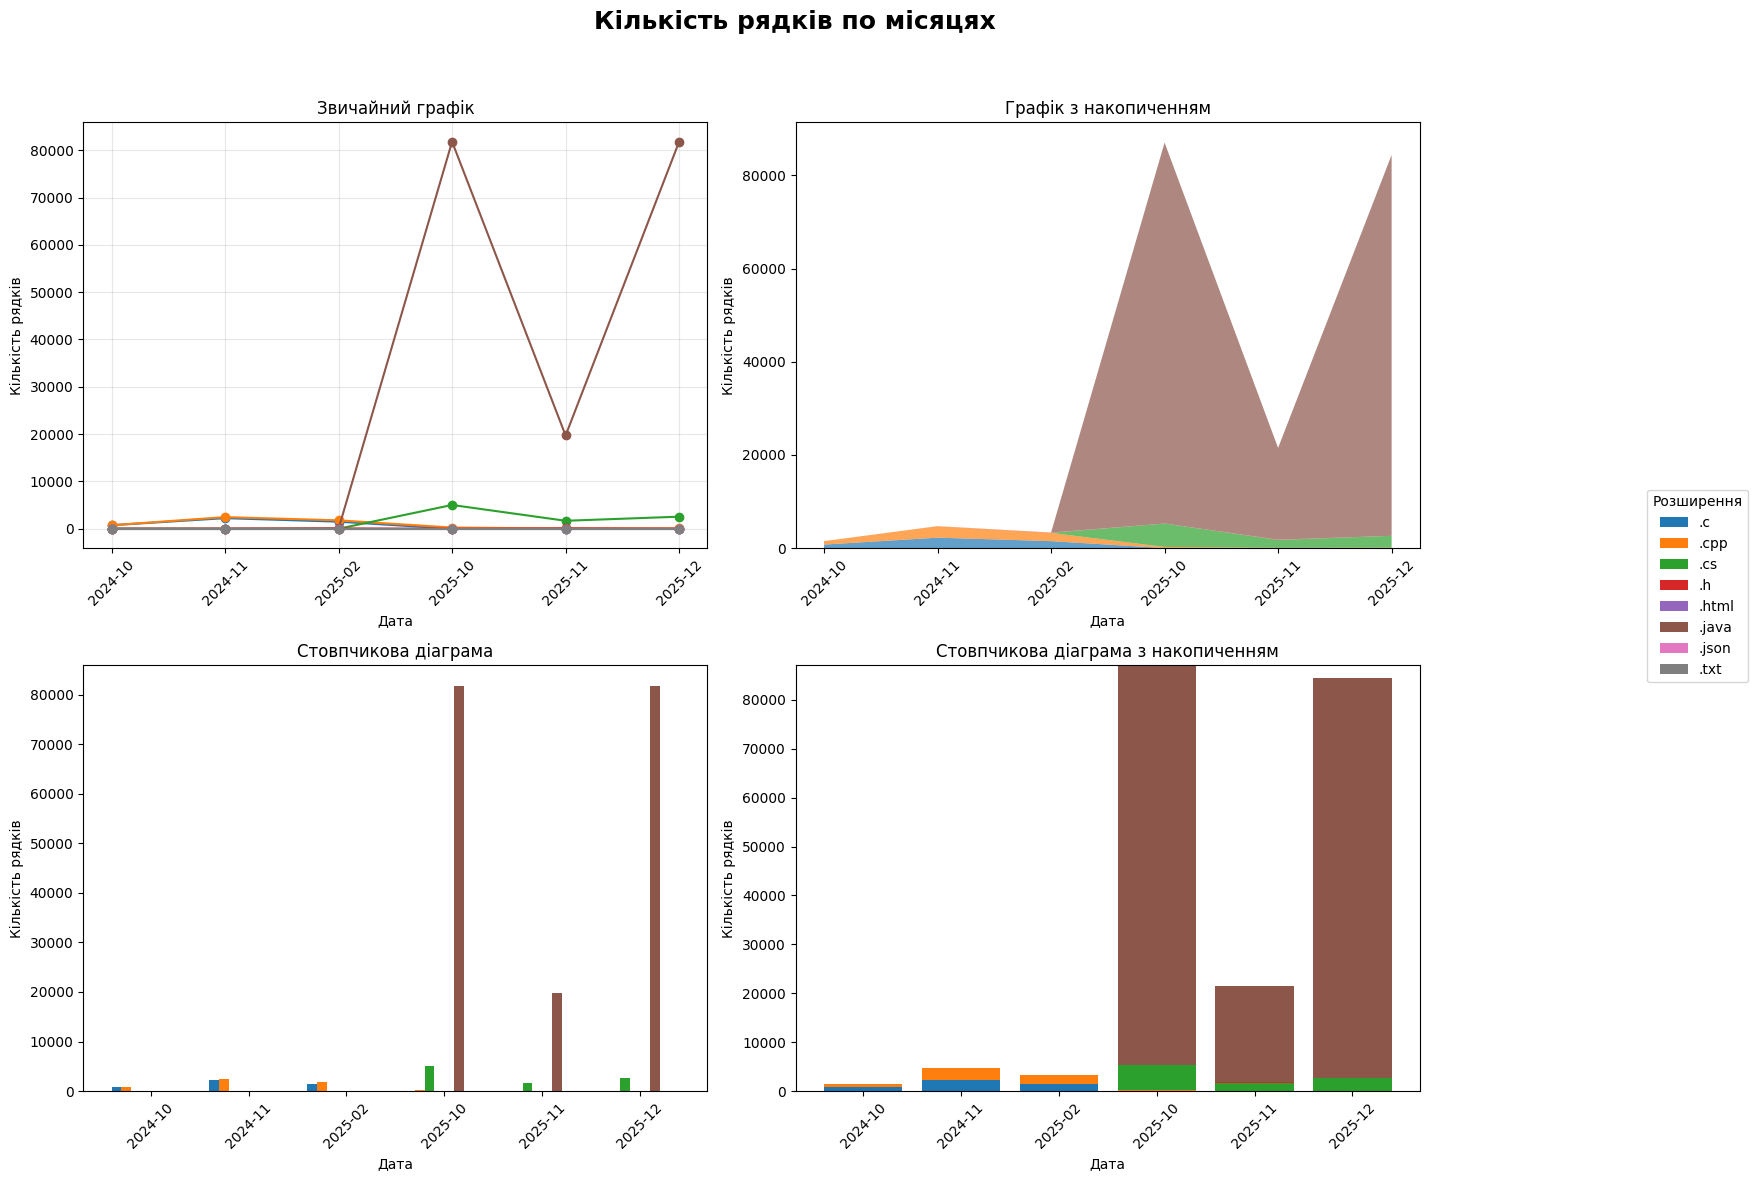

In [18]:
plot_characteristic(df, 'cnt', 'Кількість файлів')
plot_characteristic(df, 'size', 'Сумарний розмір')
plot_characteristic(df, 'lines', 'Кількість рядків')

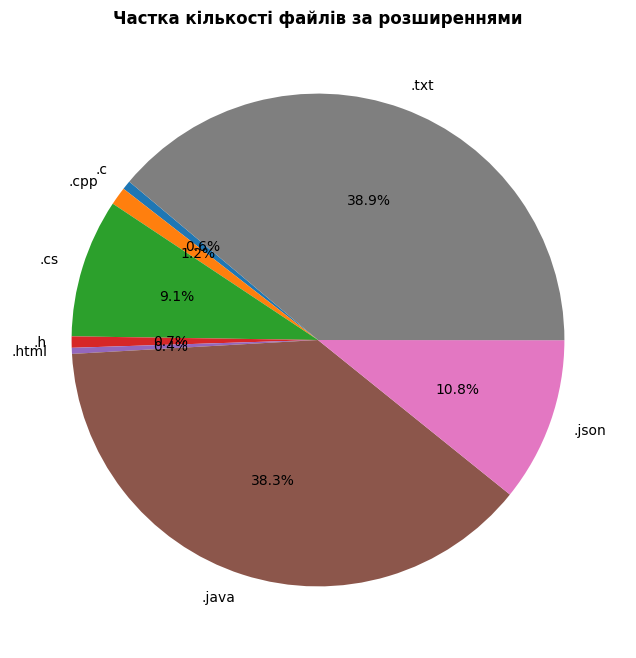

In [19]:
pie_data = df.groupby('ext')['cnt'].sum()
plt.figure(figsize=(10, 8))
plt.pie(pie_data, labels=pie_data.index, autopct=lambda p: f'{p:.1f}%' if p > 0 else '', startangle=140)
plt.title('Частка кількості файлів за розширеннями', fontweight='bold')
plt.savefig('plot_pie_chart.png', bbox_inches='tight')
plt.show()